# Import

In [27]:
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))

from src.classify import PRIORITY_MARKERS, MARKERS, count_markers

In [28]:
dataset_path = project_root / "dataset.json"

In [29]:
with open(dataset_path, "r", encoding="utf-8") as f:
    data = json.load(f)

# Score analysis

In [30]:
rows = []
for rec in data["records"]:
    text = rec["text"]

    is_priority = any(count_markers(text, m) > 0 for m in PRIORITY_MARKERS.values())
    if is_priority:
        continue

    scores = {l: count_markers(text, m) for l, m in MARKERS.items()}
    total = sum(scores.values())
    if total == 0:
        continue

    norm = {l: s / total for l, s in scores.items()}
    sorted_s = sorted(norm.items(), key=lambda x: x[1], reverse=True)

    top1 = sorted_s[0][1]
    top2 = sorted_s[1][1] if len(sorted_s) > 1 else 0.0

    rows.append(
        {
            "id": rec["id"],
            "top1_type": sorted_s[0][0],
            "top1": round(top1, 3),
            "top2": round(top2, 3),
            "margin": round(top1 - top2, 3),
        }
    )

In [31]:
df = pd.DataFrame(rows)
df

,id,top1_type,top1,top2,margin
0,R1,observation,1.000,0.000,1.000
1,R2,lesson_report,0.667,0.333,0.333
2,R4,observation,1.000,0.000,1.000
3,R6,observation,1.000,0.000,1.000


# Visualization

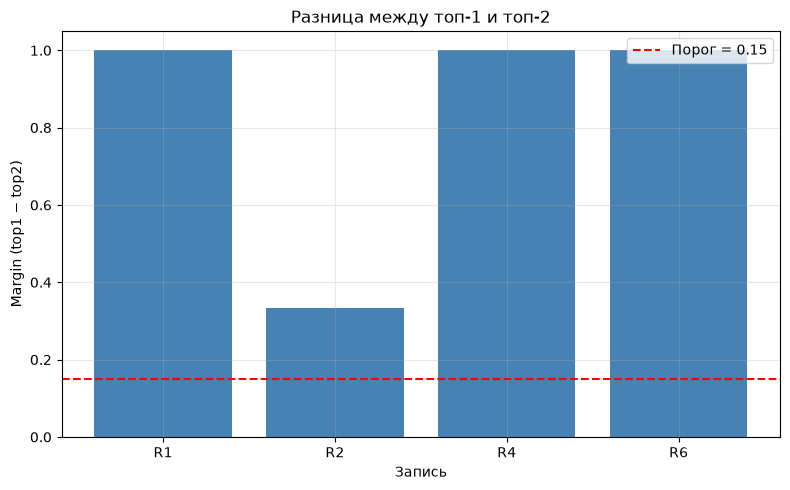

In [32]:
plt.figure(figsize=(8, 5))
plt.bar(df["id"], df["margin"], color="steelblue")
plt.axhline(y=0.15, color="red", linestyle="--", label="Порог = 0.15")
plt.xlabel("Запись")
plt.ylabel("Margin (top1 − top2)")
plt.title("Разница между топ-1 и топ-2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../images/margins.png", dpi=150)
plt.show()

# Conclusions

1. Посчитаны скоры всех типов для всех записей без применения порога. 
2. Вычислен margin = top1_score − top2_score для всех записей. 
3. Исключены приоритетные записи (R3, R5) — они классифицируются детерминированно по явным маркерам, их margin всегда равен 1.0. 
4. Сформирован pd.DataFrame для неприоритетных записей.
5. Минимальный margin: 0.333 (R2). 
6. Максимальный margin: 1.000 (R1, R4, R6). 
7. Построен график barplot: разница между топ-1 и топ-2 для всех записей. Визуально все неприоритетные записи лежат выше порога 0.15, что подтверждает корректность выбора. 
8. Выбран порог = 0.15, так как:
    - порог меньше минимального margin среди уверенных записей (0.333) -> ни одна из R1–R6 не уйдёт в unknown;
    - порог больше нуля -> полные ничьи (margin = 0) уходят в unknown;
    - диапазон (0, 0.333) даёт одинаковый результат на текущих данных, 0.15 выбран как округленная середина.
9. На 6 записях статистически обосновать порог невозможно. При росте данных порог следует подбирать на валидационной выборке, максимизируя F1 (баланс между precision и recall) или другие метрики для класса unknown.